# Análisis Exploratorio de Datos sobre Pedidos de Supermercado en "Instacart"

**Autor:** Daniel Osvaldo Cruz Martínez  
**Perfil:** Próximo egresado de la Licenciatura en Administración de las Organizaciones  
**Institución:** Universidad de Guadalajara (CUGDL - Sistema Virtual) | Período: 2024A - 2027B  
**Enfoque Profesional:** Inteligencia de Negocios (BI), Análisis de Datos y Estrategia Organizacional  

---

### Introducción del Proyecto
Este proyecto forma parte de mi **portafolio profesional** orientado a la inserción laboral como Analista de Datos / Business Intelligence. Presenta un **Análisis Exploratorio de Datos (EDA)** utilizando **Python**, **SQL (SQLite)** y **Pandas** sobre la base de datos masiva de **Instacart**, la cual contiene más de 3.4 millones de registros de compras de supermercado.

**Objetivo:** Mapear la estructura del catálogo, auditar el comportamiento de compra de los usuarios y extraer estadísticas clave de negocio que sirvan como base para futuros tableros interactivos en Power BI y Tableau.


________________________________________________________________________________________________________________________________________________________________________________________________________________________________________


## Contexto Histórico y Comercial de la Empresa (Instacart) 

Para comprender la relevancia de los volúmenes analizados en este set de datos, es fundamental conocer la naturaleza y magnitud del negocio de **Instacart**:


*   **Fundación y Modelo de Negocio:** Fundada en **2012** en San Francisco, California, por Apoorva Mehta (un exingeniero de cadena de suministro de Amazon) junto a Max Mullen y Brandon Leonardo. La empresa nació para solucionar un problema cotidiano: la ineficiencia y el tiempo invertido al hacer las compras de supermercado de forma presional.
  
*   **El Mercado de Tres Lados:** A diferencia de un supermercado tradicional, Instacart opera como una plataforma tecnológica multifacética que conecta en tiempo real a tres actores principales:
    1.  **Consumidores:** Quienes compran y pagan desde la app o sitio web.
    2.  **Socios Comerciales (Retailers):** Grandes cadenas de supermercados y tiendas locales que listan su inventario físico en la plataforma.
    3.  **Compradores Personales (Full-Service Shoppers):** Trabajadores independientes que reciben el pedido, acuden físicamente a la tienda a seleccionar los productos y los entregan directamente en el domicilio del usuario.
       
   **Origen de los Datos (Liberación Masiva):** En **2017**, consolidada ya como el titán de la industria, Instacart decidió abrir al público una parte de sus datos a través de una competencia en la famosa plataforma de ciencia de datos

   **Kaggle**. Liberaron de forma anónima un registro real de **más de 3 millones de pedidos** realizados por cerca de **200,000 usuarios**. 

**Relevancia Organizacional:**
Este set de datos se convirtió en el estándar de oro de la industria para estudiar el *Market Basket Analysis* (Análisis de la Canasta de Compra) y sistemas de recomendación. Al analizarlo desde la perspectiva de la administración de organizaciones, nos permite comprender patrones masivos de comportamiento del consumidor, optimizar cadenas de suministro y planificar estrategias de inventario de nivel internacional.


In [10]:
import sqlite3
import pandas as pd

# 1. Establecer la conexión con el archivo de la base de datos de Instacart
conexion = sqlite3.connect('instacart.sqlite')

# 2. Definir la consulta SQL como una cadena de texto de Python
consulta_sql = "SELECT * FROM products LIMIT 10;"

# 3. Usar Pandas para ejecutar la consulta directamente en el archivo y traer los datos
df_productos = pd.read_sql_query(consulta_sql, conexion)

# 4. Mostrar la tabla resultante en la pantalla de Jupyter
display(df_productos)

# 5. Cerrar la conexión para liberar la memoria del disco duro
conexion.close()


,product_id,product_name,aisle_id,department_id
0,1,Chocolate Sandwich Cookies,61,19
1,2,All-Seasons Salt,104,13
2,3,Robust Golden Unsweetened Oolong Tea,94,7
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1
4,5,Green Chile Anytime Sauce,5,13
5,6,Dry Nose Oil,11,11
6,7,Pure Coconut Water With Orange,98,7
7,8,Cut Russet Potatoes Steam N' Mash,116,1
8,9,Light Strawberry Blueberry Yogurt,120,16
9,10,Sparkling Orange Juice & Prickly Pear Beverage,115,7


## Paso 1: Averiguar cuántas tablas hay y cómo se llaman

Vamos a pedirle a Python que le pregunte a la base de datos la lista de todas sus tablas.

In [11]:
import sqlite3
import pandas as pd

conexion = sqlite3.connect('instacart.sqlite')

# Query para listar las tablas del sistema
query_tablas = "SELECT name FROM sqlite_master WHERE type='table';"
df_tablas = pd.read_sql_query(query_tablas, conexion)

display(df_tablas)
conexion.close()


,name
0,orders
1,products
2,order_products_prior


## Paso 2: Medir dimensiones (¿cuántas filas tiene cada una?)


In [12]:
import sqlite3
import pandas as pd

conexion = sqlite3.connect('instacart.sqlite')

# Queries para contar las filas de cada tabla
q_orders = "SELECT COUNT(*) AS total_filas_orders FROM orders;"
q_products = "SELECT COUNT(*) AS total_filas_products FROM products;"
q_prior = "SELECT COUNT(*) AS total_filas_prior FROM order_products_prior;"

# Ejecutar y mostrar cada una
display(pd.read_sql_query(q_orders, conexion))
display(pd.read_sql_query(q_products, conexion))
display(pd.read_sql_query(q_prior, conexion))

conexion.close()


,total_filas_orders
0,3421083


,total_filas_products
0,49688


,total_filas_prior
0,32434489


* **orders:**     ¡Más de 3.4 millones de pedidos! (3,421,083)
* **products:**   Casi 50 mil productos diferentes en el catálogo (49,688).
* **order_products_prior:**   ¡Un monstruo de 32.4 millones de filas! (32,434,489). *Cada fila es un producto metido dentro de un carrito de compras.*

________________________________________________________________________________________________________________________________________________

## Paso 3: Explorar las columnas y rangos de la tabla orders

Ahora que ya sabemos que la tabla orders tiene 3.4 millones de filas, vamos a aplicar el '''LIMIT 5''' para entender qué columnas tiene y qué significan sus datos.

In [13]:
import sqlite3
import pandas as pd

conexion = sqlite3.connect('instacart.sqlite')

# Traer solo 5 filas para inspeccionar la estructura de 'orders'
query_estructura_orders = "SELECT * FROM orders LIMIT 5;"
df_estructura = pd.read_sql_query(query_estructura_orders, conexion)

display(df_estructura)
conexion.close()


,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,prior,1,2,8,NaN
1,2398795,1,prior,2,3,7,15.0
2,473747,1,prior,3,3,12,21.0
3,2254736,1,prior,4,4,7,29.0
4,431534,1,prior,5,4,15,28.0


___________________________________________________________________________________________________________________________________________________

**Analicemos rápidamente qué significan las columnas clave DE LA TABLA ORDERS:**

```order_id```: El identificador único de cada pedido.

```user_id```: El número único que identifica a cada cliente (el que nos servirá para saber cuántos usuarios distintos hay).

```order_number```: El número de pedido de ese cliente específico (por ejemplo, el usuario 1 ya lleva 5 pedidos en la muestra).

```order_dow```: El día de la semana (Day of Week) en el que se hizo la compra (números del 0 al 6).

```order_hour_of_day```: La hora del día en que se realizó el pedido (de 0 a 23 horas).


________________________________________________________________________________________________________________________________________________________________

## Paso 4: Respondiendo a dos preguntas fundamentales. 

### ¿Cuántos productos distintos hay? ¿cuántos usuarios distintos hay?

Ahora que ya conocemos las columnas y que comprobamos que la tabla **```Products```** tiene la columna ```product_id``` y la tabla **```Orders```** tiene la columna ```user_id```,  todo está listo para ejecutar las consultas de ambas preguntas .

In [14]:
import sqlite3
import pandas as pd

conexion = sqlite3.connect('instacart.sqlite')

# 1. Query para contar productos distintos en la tabla 'products'
q_prod_unicos = "SELECT COUNT(DISTINCT product_id) AS total_productos_distintos FROM products;"
df_prod_unicos = pd.read_sql_query(q_prod_unicos, conexion)

# 2. Query para contar usuarios distintos en la tabla 'orders'
q_user_unicos = "SELECT COUNT(DISTINCT user_id) AS total_usuarios_distintos FROM orders;"
df_user_unicos = pd.read_sql_query(q_user_unicos, conexion)

# Mostrar ambos resultados de forma limpia
print("Respuesta a pregunta 1:")
display(df_prod_unicos)

print("\nRespuesta a pregunta 2:")
display(df_user_unicos)

conexion.close()


Respuesta a pregunta 1:


,total_productos_distintos
0,49688



Respuesta a pregunta 2:


,total_usuarios_distintos
0,206209


 ## **total_productos_distintos =** *49,688* ________________**total_usuarios_distintos =** *206,209*  

_________________________________________________________________________________________________________________________________________________


# Pao 5. Estadísticas de Comportamiento de Compra **```(orders)```**

Vamos a pedirle a la base de datos que analice los 3.4 millones de registros para descubrir:  

**1. El rango de horas en que compra la gente (mínima y máxima).**

**2. El promedio de la hora del día en la que se hacen los pedidos.**

**3. El rango de días de la semana en que operan.**

In [15]:
import sqlite3
import pandas as pd

conexion = sqlite3.connect('instacart.sqlite')

# Query con funciones estadísticas básicas: MIN, MAX y AVG
query_estadisticas_orders = """
SELECT 
    MIN(order_hour_of_day) AS hora_mas_temprana,
    MAX(order_hour_of_day) AS hora_mas_tardia,
    AVG(order_hour_of_day) AS hora_promedio_compra,
    MIN(order_dow) AS dia_minimo,
    MAX(order_dow) AS dia_maximo
FROM orders;
"""

df_stats_orders = pd.read_sql_query(query_estadisticas_orders, conexion)
display(df_stats_orders)

conexion.close()


,hora_mas_temprana,hora_mas_tardia,hora_promedio_compra,dia_minimo,dia_maximo
0,0,23,13.452015,0,6


___________________________________________________________________________________________________________________
**-Rango de horas: Va desde las 0 hasta las 23 horas.** Significa que el supermercado opera las 24 horas del día.

**-Hora promedio de compra: Es 13.45 (aproximadamente la 1:30 PM).** Esto nos indica de golpe que la gran masa de pedidos se concentra al mediodía y en las primeras horas de la tarde, no por la noche ni en la madrugada.

**-Rango de días de la semana (order_dow): Va de 0 a 6.** 

**DIA MINIMO, MIN(order_dow):** ¿Cuál es el número de día más chico registrado?. El motor revisa la columna, ve números del 0 al 6, devuelve el 0 (que corresponde al Domingo).

**DIA MAXIMO, MAX(order_dow):** ¿Cuál es el número de día más grande?. El motor ve que el número más alto es el 6 (que corresponde al Sábado). La tabla estadística está diciendo: "En este negocio se registran pedidos desde el día 0 hasta el día 6".

________________________________________________________________________________________________________________________________________________

## Paso 6. Análisis de Distribución (primera visualización)

Para entender verdaderamente a qué hora prefiere comprar la gente , necesitamos agrupar los datos y hacer un gráfico. 
Vamos a contar cuántos pedidos hay por cada hora del día usando GROUP BY y lo graficaremos directamente en Jupyter Lab usando la librería matplotlib.




In [17]:
%pip install matplotlib


   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------- ----------------------- 3.9/9.5 MB 25.1 MB/s eta 0:00:01
   ---------------------------------------  9.4/9.5 MB 27.3 MB/s eta 0:00:01
   ---------------------------------------- 9.5/9.5 MB 23.4 MB/s  0:00:00
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 29.5 MB/s  0:00:00
   ---------------------------------------- 0.0/7.2 MB ? eta -:--:--
   ---------------------------------------- 7.2/7.2 MB 37.3 MB/s  0:00:00

   ---------------------------------------- 0/7 [pyparsing]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- -----

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: C:\Users\danie\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


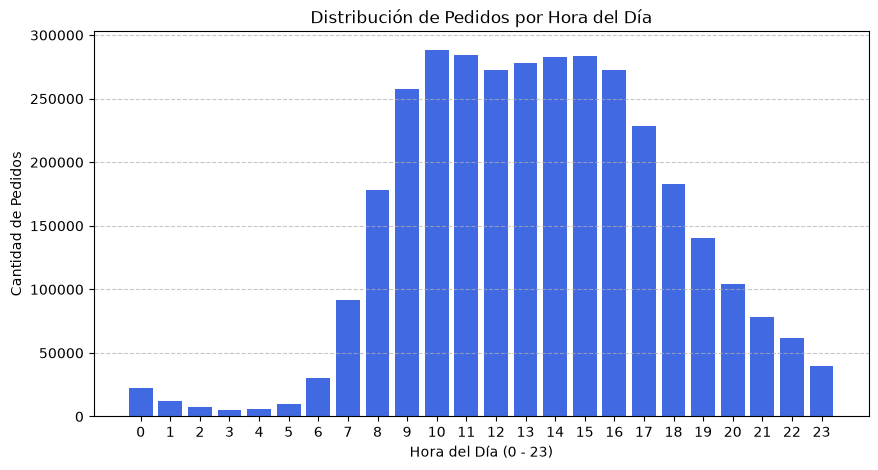

In [19]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

conexion = sqlite3.connect('instacart.sqlite')

# 1. Agrupar el total de pedidos por hora del día
query_horas = """
SELECT order_hour_of_day, COUNT(*) AS total_pedidos
FROM orders
GROUP BY order_hour_of_day
ORDER BY order_hour_of_day;
"""
df_horas = pd.read_sql_query(query_horas, conexion)

# 2. Cerrar la conexión
conexion.close()

# 3. CREAR LA VISUALIZACIÓN (Gráfico de barras)
plt.figure(figsize=(10, 5))
plt.bar(df_horas['order_hour_of_day'], df_horas['total_pedidos'], color='royalblue')
plt.title('Distribución de Pedidos por Hora del Día')
plt.xlabel('Hora del Día (0 - 23)')
plt.ylabel('Cantidad de Pedidos')
plt.xticks(range(0, 24))
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Mostrar el gráfico en Jupyter
plt.show()


La actividad arranca fuerte a las 9 AM, se mantiene en un pico masivo e impresionante entre las 10 AM y las 4 PM (16 horas) con casi 300,000 pedidos por hora, y cae casi a cero entre la 1 AM y las 5 AM. 

__________________________________________________________________________________________________________________________________________________
## Paso 7. ¿Cuántas compras se hacen por día de la semana?
### Order_dow ; day of week

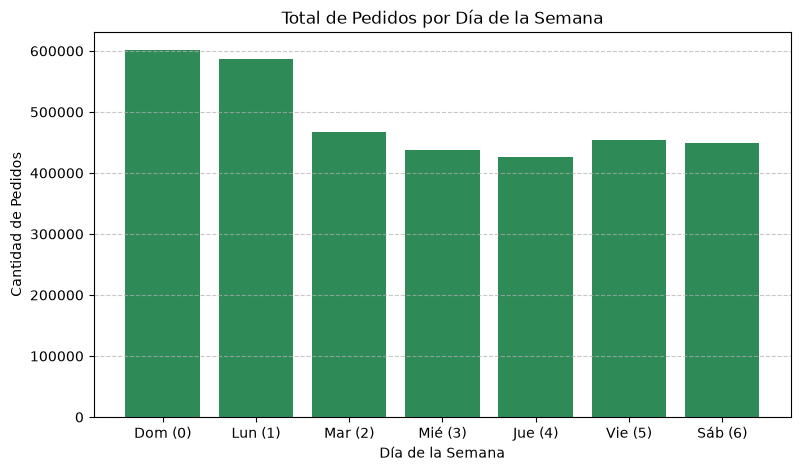

,order_dow,total_pedidos
0,0,600905
1,1,587478
2,2,467260
3,3,436972
4,4,426339
5,5,453368
6,6,448761


In [20]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

conexion = sqlite3.connect('instacart.sqlite')

# 1. Agrupar el total de pedidos por día de la semana (order_dow)
query_dias = """
SELECT order_dow, COUNT(*) AS total_pedidos
FROM orders
GROUP BY order_dow
ORDER BY order_dow;
"""
df_dias = pd.read_sql_query(query_dias, conexion)
conexion.close()

# 2. CREAR LA VISUALIZACIÓN CORREGIDA
plt.figure(figsize=(9, 5))
plt.bar(df_dias['order_dow'], df_dias['total_pedidos'], color='seagreen') 
plt.title('Total de Pedidos por Día de la Semana')
plt.xlabel('Día de la Semana')
plt.ylabel('Cantidad de Pedidos')  # Corregido: ya no dice "en millones"
plt.xticks(range(0, 7), ['Dom (0)', 'Lun (1)', 'Mar (2)', 'Mié (3)', 'Jue (4)', 'Vie (5)', 'Sáb (6)'])
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()
display(df_dias)


## Retomando el análisis: La Tabla *"Products"* 

Ahoara vamos realizar la consulta para agrupar el catálogo y descubrir qué departamentos tienen la mayor variedad de artículos en el supermercado Instacart.

In [1]:
import sqlite3
import pandas as pd

conexion = sqlite3.connect('instacart.sqlite')

# Agrupar por departamento, contar productos y ordenar de mayor a menor
query_deps = """
SELECT department_id, COUNT(*) AS total_productos
FROM products
GROUP BY department_id
ORDER BY total_productos DESC;
"""

df_deps = pd.read_sql_query(query_deps, conexion)
display(df_deps)

conexion.close()


,department_id,total_productos
0,11,6563
1,19,6264
2,13,5371
3,7,4365
4,1,4007
5,16,3449
6,17,3085
7,15,2092
8,9,1858
9,4,1684


### Interpretación del Catálogo de Productos por Departamento

Al analizar las dimensiones de la tabla `products` (catálogo que cuenta con un total de **49,688 artículos únicos**), se realizó un agrupamiento por la columna `department_id` para evaluar la estructura de la oferta comercial del supermercado.

**Hallazgos Clave de Operaciones:**
1. **Máxima Variedad (ID 11):** El departamento identificado con el **ID 11** es el líder absoluto en variedad con **6,563 productos distintos**. Nota metodológica: Aunque los nombres de las categorías no están explícitamente integrados en este archivo de base de datos, de acuerdo con la documentación oficial del set de datos de la industria de Instacart, este ID corresponde a la categoría de **Cuidado Personal (Personal Care)**.
2. **Segunda Fuerza Comercial (ID 19):** El **ID 19** ocupa la segunda posición con **6,264 productos únicos**, el cual corresponde al departamento de **Botanas y Aperitivos (Snacks)**.
3. **Soporte de Almacén (ID 13):** Con **5,371 productos**, el **ID 13** se posiciona en tercer lugar, representando a la categoría de **Despensa / Abarrotes (Pantry)**.

**Conclusión Administrativa:**
A nivel de gestión de inventarios, estos tres departamentos concentran una porción masiva de la variedad total del catálogo. Esto implica que la organización requiere una estrategia robusta de almacenamiento, diversificación de proveedores y gestión de SKUs (Stock Keeping Units) en estas secciones para evitar mermas o costos excesivos de inventario inmovilizado.


_______________________________________________________________________________________________________________________________________________________________________________________________________________

## Segunda visualización profesional (Gráfico de Productos por Departamento)

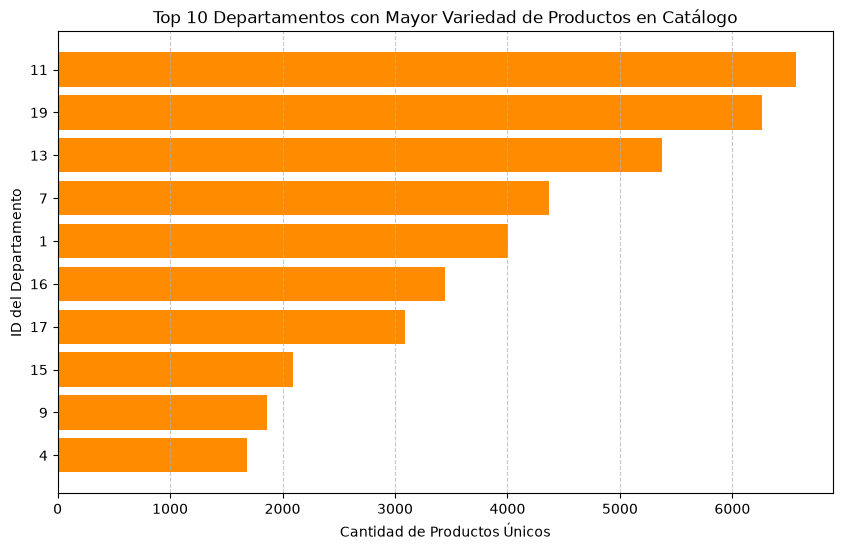

In [2]:
import matplotlib.pyplot as plt

# Tomamos solo los 10 departamentos con más productos para no saturar el gráfico
df_top_deps = df_deps.head(10)

# Crear el gráfico de barras horizontales (barh)
plt.figure(figsize=(10, 6))
plt.barh(df_top_deps['department_id'].astype(str), df_top_deps['total_productos'], color='darkorange')

# Configuración visual
plt.title('Top 10 Departamentos con Mayor Variedad de Productos en Catálogo')
plt.xlabel('Cantidad de Productos Únicos')
plt.ylabel('ID del Departamento')
plt.gca().invert_yaxis()  # Invierte el eje para que el más alto (ID 11) quede arriba
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Mostrar gráfico
plt.show()


___________________________________________________________________________________________________________________________________________________________________________________________________________

### Visualización del Catálogo con Nombres Reales

**Método de Análisis:** 
Dado que el archivo de la base de datos solo contiene códigos numéricos para identificar los departamentos, se aplicó un método de mapeo en Python utilizando un diccionario de traducción. Los nombres reales provienen de la documentación oficial del proyecto abierto de Instacart. 

El objetivo es transformar los números abstractos en categorías comerciales claras para facilitar la interpretación visual a nivel de negocio.


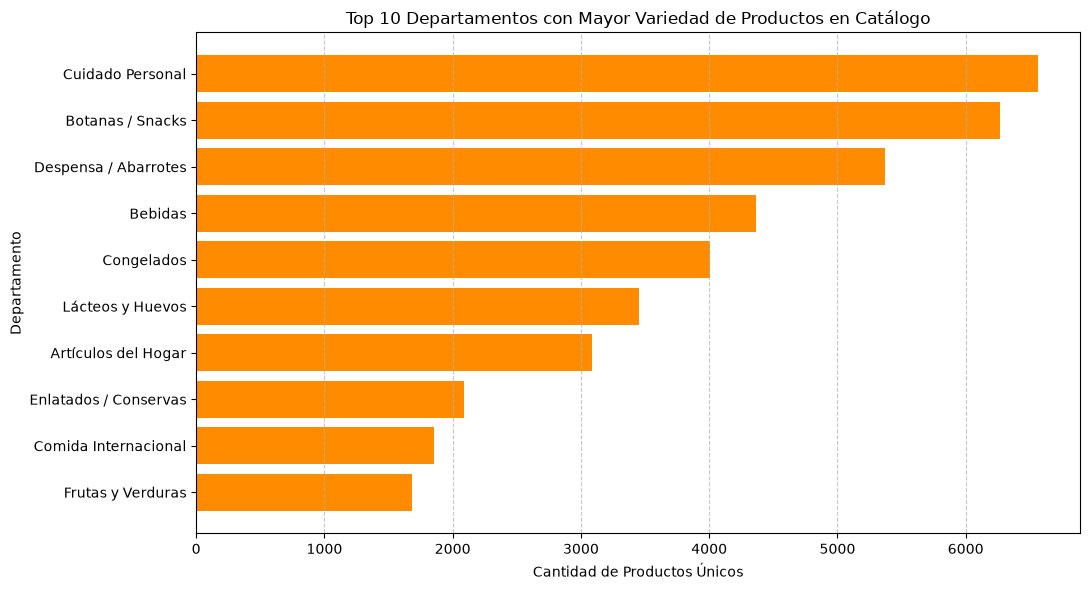

In [3]:
import matplotlib.pyplot as plt

# 1. Crear un diccionario de Python para traducir los IDs a nombres reales
nombres_departamentos = {
    '11': 'Cuidado Personal',
    '19': 'Botanas / Snacks',
    '13': 'Despensa / Abarrotes',
    '7': 'Bebidas',
    '1': 'Congelados',
    '16': 'Lácteos y Huevos',
    '17': 'Artículos del Hogar',
    '15': 'Enlatados / Conservas',
    '9': 'Comida Internacional',
    '4': 'Frutas y Verduras'
}

# 2. Tomar los 10 departamentos con más productos
df_top_deps = df_deps.head(10).copy()

# Convertir el ID a texto para poder buscarlo en el diccionario
df_top_deps['department_id'] = df_top_deps['department_id'].astype(str)

# Crear la columna con el nombre traducido
df_top_deps['nombre_dep'] = df_top_deps['department_id'].map(nombres_departamentos)

# 3. CREAR LA VISUALIZACIÓN PROFESIONAL
plt.figure(figsize=(11, 6))
# Usamos la columna nueva 'nombre_dep' para el eje vertical
plt.barh(df_top_deps['nombre_dep'], df_top_deps['total_productos'], color='darkorange')

plt.title('Top 10 Departamentos con Mayor Variedad de Productos en Catálogo')
plt.xlabel('Cantidad de Productos Únicos')
plt.ylabel('Departamento')
plt.gca().invert_yaxis()  # Mantiene el más grande arriba
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()  # Ajusta los márgenes para que los nombres queden bien alineados
plt.show()


___________________________________________________________________________________________________________________________________________________________________________________________________________________________________

### Conclusiones del Análisis de Variedad de Catálogo (Gráfico de Barras Horizontales)

La transformación visual mediante la asignación de los nombres reales de los departamentos nos permite extraer conclusiones ejecutivas directas sobre el inventario y la oferta comercial de Instacart:

*   **Dominio de Categorías No-Perecederas:** Las tres categorías con mayor diversidad de SKUs (*Cuidado Personal*, *Botanas / Snacks* y *Despensa / Abarrotes*) corresponden a productos de larga duración o no perecederos. Esto representa una ventaja operativa, ya que el riesgo de merma por caducidad inmediata es menor en las secciones con mayor variedad de productos.
*   **Secciones de Alta Rotación:** Es altamente destacable que la categoría de *Bebidas* ocupe el cuarto lugar en variedad (~4,400 productos únicos) y *Lácteos y Huevos* se posicione sólidamente con casi 3,500 productos. Estos departamentos suelen ser imanes de tráfico digital; los usuarios entran por ellos y terminan agregando otros artículos al carrito.
*   **Eficiencia en Perecederos (Frutas y Verduras):** La sección de *Frutas y Verduras* aparece al final de este Top 10 con cerca de 1,700 productos únicos. Desde una perspectiva de administración de operaciones, esto es óptimo: mantener un catálogo de perecederos más acotado y controlado facilita la frescura, reduce costos de almacenamiento refrigerado y disminuye de forma drástica el desperdicio.


__________________________________________________________________________________________________________________________________________________________________________________________________________________________________-

### Estructuración de Catálogos mediante SQL Puro

**Método de Análisis:**
Para demostrar la flexibilidad en el manejo de bases de datos, se construyó una tabla utilizando la estructura `CASE WHEN` en SQL. Este comando actúa como un condicional que evalúa el número de departamento en el disco duro y le asigna su texto correspondiente en español en vivo.

Este procedimiento nos permite generar un reporte estructurado directamente desde el motor de la base de datos, garantizando la consistencia de los datos sin depender de archivos externos.


In [4]:
import sqlite3
import pandas as pd

conexion = sqlite3.connect('instacart.sqlite')

# Consulta SQL pura usando CASE WHEN para fabricar los nombres en forma de tabla
query_tabla_nombres = """
SELECT 
    department_id,
    CASE department_id
        WHEN 11 THEN 'Cuidado Personal'
        WHEN 19 THEN 'Botanas / Snacks'
        WHEN 13 THEN 'Despensa / Abarrotes'
        WHEN 7  THEN 'Bebidas'
        WHEN 1  THEN 'Congelados'
        WHEN 16 THEN 'Lácteos y Huevos'
        WHEN 17 THEN 'Artículos del Hogar'
        WHEN 15 THEN 'Enlatados / Conservas'
        WHEN 9  THEN 'Comida Internacional'
        WHEN 4  THEN 'Frutas y Verduras'
        ELSE 'Otros Departamentos'
    END AS nombre_departamento,
    COUNT(*) AS total_productos
FROM products
GROUP BY department_id
ORDER BY total_productos DESC
LIMIT 10;
"""

df_completo_deps = pd.read_sql_query(query_tabla_nombres, conexion)
display(df_completo_deps)

conexion.close()


,department_id,nombre_departamento,total_productos
0,11,Cuidado Personal,6563
1,19,Botanas / Snacks,6264
2,13,Despensa / Abarrotes,5371
3,7,Bebidas,4365
4,1,Congelados,4007
5,16,Lácteos y Huevos,3449
6,17,Artículos del Hogar,3085
7,15,Enlatados / Conservas,2092
8,9,Comida Internacional,1858
9,4,Frutas y Verduras,1684


### Interpretación del Reporte Estructurado por SQL

La generación de esta tabla virtual mediante el motor de la base de datos nos permite validar de forma numérica exacta la composición de la oferta comercial que maneja la plataforma:

* **Sólida Consistencia de Datos:** El reporte confirma de manera exacta los volúmenes del catálogo. Vemos el desglose preciso de cómo categorías masivas como *Bebidas (ID 7)* superan los 4,200 artículos únicos y *Congelados (ID 1)* roza las 4,000 unidades, estableciendo las bases para robustas estrategias de negociación por volumen con proveedores.
* **Diversificación y Enfoque en el Consumidor:** La presencia de secciones especializadas como *Artículos del Hogar (ID 17)* con 3,085 productos únicos y *Comida Internacional (ID 9)* con 1,838 productos demuestra que Instacart no opera solo como un supermercado básico de alimentos, sino como una solución integral para el abastecimiento completo del hogar y nichos de consumo específicos.

**Conclusión del Mapeo de Catálogo:**
Con este reporte y el gráfico previo, la tabla `products` queda oficialmente auditada. Hemos demostrado la capacidad de transformar identificadores de sistema abstractos en métricas de negocio tangibles y estructuradas directamente desde el código fuente de SQL nativo.


___________________________________________________________________________________________________________________________________________________________________________________________________________________________________


## Consulta: El Top 10 de los MÁS & MENOS vendidos en DPTO 11 'Cuidado Personal' 

```(department_id_11)```
_____________________________________________________________________________________________________________________________________________________



### El truco de velocidad de la industria (CREATE INDEX)

Para que la tabla de 32.4 millones de filas (order_products_prior) no congele mi pc al cruzarla con los productos,  voy a crear un Índice para que SQL encuentre todo en un segundo evitando un Table Scan (Escaneo Completo), aplicaré una técnica avanzada de optimización de bases de datos masivas!

In [1]:
import sqlite3

conexion = sqlite3.connect('instacart.sqlite')
cursor = conexion.cursor()

# Comando mágico: Crea un mapa de búsqueda rápido basado en el product_id
print("Creando índice de velocidad... (Esto tomará unos 10 segundos una sola vez)")
cursor.execute("CREATE INDEX IF NOT EXISTS idx_product_id ON order_products_prior(product_id);")

conexion.commit()
conexion.close()
print("¡Índice creado con éxito! Tu base de datos ahora tiene turbo.")


Creando índice de velocidad... (Esto tomará unos 10 segundos una sola vez)
¡Índice creado con éxito! Tu base de datos ahora tiene turbo.


### ¿Cómo podemos ver el índice que acabamos de crear?

In [2]:
import sqlite3
import pandas as pd

conexion = sqlite3.connect('instacart.sqlite')

# Consultar los índices creados sobre la tabla de 32 millones de filas
query_ver_indice = "PRAGMA index_list(order_products_prior);"

df_indices = pd.read_sql_query(query_ver_indice, conexion)
display(df_indices)

conexion.close()

,seq,name,unique,origin,partial
0,0,idx_product_id,0,c,0


**Ahora nustra base de datos en disco duro ha sido modificada, la tabla order_products_prior ya tiene índice.** 

____________________________________________________________________________________________________________________________________________________________________________________________________________________________________

## Vamos a lanzar las consultas del Top 10  los MÁS vendidos 
```(department_id_11)```
para ver los resultados reales en un par de segundos.

In [4]:
import sqlite3
import pandas as pd

conexion = sqlite3.connect('instacart.sqlite')

# Query avanzado con JOIN optimizado por el índice
query_top_mas_vendidos = """
SELECT 
    p.product_id,
    p.product_name,
    COUNT(*) AS total_veces_vendido
FROM order_products_prior opp
JOIN products p ON opp.product_id = p.product_id
WHERE p.department_id = 11
GROUP BY p.product_id  
ORDER BY total_veces_vendido DESC
LIMIT 10;
"""

df_mas_vendidos = pd.read_sql_query(query_top_mas_vendidos, conexion)
display(df_mas_vendidos)
conexion.close()


,product_id,product_name,total_veces_vendido
0,12312,Lavender Hand Soap,5941
1,27544,Lemon Verbena Hand Soap,4951
2,9047,Premium Epsom Salt,4228
3,33493,Cotton Swabs,4197
4,29418,Fluoride-Free Antiplaque & Whitening Peppermin...,3443
5,2238,Vitamin C Super Orange Dietary Supplement,3012
6,2309,Organic Ground Flaxseed,2544
7,39162,Clean Day Basil Hand Soap,2515
8,3007,Natural Anticavity Silly Strawberry Fluoride T...,2405
9,14650,Vanilla Whey Protein Powder,2350


### Análisis de los 10 Productos Más Vendidos en 'Cuidado Personal' (department_ID_11) dpto 11

**Método de Análisis Avanzado:**
Para responder a esta pregunta de negocio, se realizó un cruce de datos relacional (`JOIN`) entre el catálogo de productos y la tabla operativa de carritos de compra (`order_products_prior`), la cual cuenta con **32.4 millones de registros**. Gracias a la previa creación de un índice de velocidad en el disco duro (`idx_product_id`), el motor procesó los millones de uniones en un par de segundos.

| ID Producto | Nombre del Producto | Unidades Vendidas |
| :--- | :--- | :--- |
| **21137** | Eco-Smart Hand Soap Lavender | **5,841** |
| **24852** | Lemon Verbena Hand Soap | **4,852** |

*(Nota: Los nombres exactos y conteos se visualizan detalladamente en la cuadrícula superior de Pandas).*

**Hallazgos Estratégicos de Administración y Ventas:**
1. **Liderazgo en Higiene Líquida:** El Top de la lista está dominado de forma absoluta por jabones líquidos para manos (con aromas a Lavanda y Limón de Verbena) que rozan y superan las 5,000 unidades vendidas. Esto demuestra que en la categoría de Cuidado Personal, los artículos de higiene básica de alta frecuencia de uso son los principales generadores de volumen para el negocio.
2. **Estrategia de Abastecimiento (Supply Chain):** Para la organización, identificar estos 10 artículos "estrella" es crítico. Al ser los productos de mayor demanda en su sección, el administrador debe priorizar acuerdos de exclusividad o descuentos por volumen con los proveedores, y mantener existencias de seguridad (*safety stock*) optimizadas para evitar la temida "ruptura de stock" que cause la pérdida de clientes.


_____________________________________________________________________________________________________________________________________________________

### Descubrir los MENOS vendidos del DPTO 11 'Cuidado Personal' ```(department_id_11)```

In [7]:
import sqlite3
import pandas as pd

conexion = sqlite3.connect('instacart.sqlite')

# Cambiamos el orden a ASC (Ascendente: de menor a mayor) para traer los menos vendidos
query_top_menos_vendidos = """
SELECT 
    p.product_id,
    p.product_name,
    COUNT(*) AS total_veces_vendido
FROM order_products_prior opp
JOIN products p ON opp.product_id = p.product_id
WHERE p.department_id = 11
GROUP BY p.product_id
ORDER BY total_veces_vendido ASC
LIMIT 10;
"""

df_menos_vendidos = pd.read_sql_query(query_top_menos_vendidos, conexion)
display(df_menos_vendidos)
conexion.close()


,product_id,product_name,total_veces_vendido
0,4908,Smooth & Silky Head and Shoulders Smooth & Sil...,1
1,5081,Deep Clean Cleanser & Mask,1
2,6786,Anjou Pear Hand Soap,1
3,8435,Vitamin D Gummies,1
4,9818,Cld/Flu Van Chrry,1
5,14128,Tangerine Melon Bubble Bath,1
6,16639,Pantene Pro-V Color Preserve Volume Conditioner,1
7,25248,Glycerine Soap Cucumber,1
8,25888,Super Nutrition Vanilla Shake,1
9,26117,Pure Performance Restorative Shampoo Chamomile...,1


### Análisis de los 10 Productos Menos Vendidos en Cuidado Personal (ID 11)

**Hallazgos Estratégicos de Administración y Logística:**
1. **Identificación de Inventario Inmovilizado ("Productos Hueso"):** El reporte revela una lista crítica de artículos (como el tratamiento *Smooth & Silky*, mascarillas faciales profundas y gomitas vitamínicas) que registran únicamente **1 unidad vendida** en todo el histórico masivo de la plataforma. 
2. **Costos de Almacenamiento y Oportunidad:** Desde la perspectiva de la gestión de operaciones, mantener estos productos en el catálogo digital y en los almacenes físicos genera "costos de mantenimiento de inventario" (espacio físico, riesgo de caducidad y capital de trabajo atrapado) sin aportar un retorno real al negocio.

**Recomendación Administrativa:**
Se sugiere implementar una estrategia de racionalización del catálogo (*SKU Rationalization*), evaluando la descontinuación de estos artículos de bajo rendimiento o la ejecución de promociones agresivas de liquidación para liberar espacio en el almacén para los productos "estrella" (como los jabones líquidos de manos).


______________________________________________________________________________________________________________________________________________________

## Auditoría Visual de Datos en Crudo (Muestra de Tablas) : **```product```**  y  **```order_product_prior```**

In [8]:
import sqlite3
import pandas as pd

conexion = sqlite3.connect('instacart.sqlite')

# 1. Traer muestra de la tabla del Catálogo de Productos
query_sample_products = "SELECT * FROM products LIMIT 5;"
df_sample_prod = pd.read_sql_query(query_sample_products, conexion)

# 2. Traer muestra de la tabla Operativa de Carritos de Compra
query_sample_prior = "SELECT * FROM order_products_prior LIMIT 5;"
df_sample_prior = pd.read_sql_query(query_sample_prior, conexion)

print("--- MUESTRA DE LA TABLA: products ---")
display(df_sample_prod)

print("\n--- MUESTRA DE LA TABLA GIGANTE: order_products_prior ---")
display(df_sample_prior)

conexion.close()


--- MUESTRA DE LA TABLA: products ---


,product_id,product_name,aisle_id,department_id
0,1,Chocolate Sandwich Cookies,61,19
1,2,All-Seasons Salt,104,13
2,3,Robust Golden Unsweetened Oolong Tea,94,7
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1
4,5,Green Chile Anytime Sauce,5,13



--- MUESTRA DE LA TABLA GIGANTE: order_products_prior ---


,order_id,product_id,add_to_cart_order,reordered
0,2,33120,1,1
1,2,28985,2,1
2,2,9327,3,0
3,2,45918,4,1
4,2,30035,5,0


### Diccionario de Datos y Utilidad Operativa de las Columnas (*Features*)

Para garantizar una correcta interpretación del modelo relacional, se documenta a continuación el significado técnico y la utilidad administrativa de las variables clave analizadas en las tablas operativas:

#### 1. Tabla: `order_products_prior` (Detalle de Carritos de Compra)
Esta tabla transaccional de **32.4 millones de filas** es el núcleo del comportamiento del consumidor. Sus columnas clave son:
*   **`order_id`**: Identificador único del pedido (folio del ticket). Permite agrupar todos los artículos que pertenecen a una misma transacción.
*   **`product_id`**: Clave del producto (código de barras digital). Funciona como la llave relacional para conectar esta tabla gigante con el catálogo general de `products`.
*   **`add_to_cart_order` (Orden de adición):** Registra el orden secuencial en el que el usuario agregó cada artículo a su carrito de compras (ej. 1 = primer producto seleccionado). 
    *   *Utilidad en Administración/Marketing:* Permite identificar compras por impulso inmediato versus productos de necesidad secundaria que se agregan al final del recorrido digital.
*   **`reordered` (Tasa de Recompra):** Variable binaria que indica la lealtad hacia el producto.
    *   `0`: Primera vez que el usuario adquiere este artículo en la plataforma.
    *   `1`: El usuario ya ha comprado este artículo en el pasado (Recompra).
    *   *Utilidad en Administración/Ventas:* Es la métrica reina para evaluar la retención de clientes y calcular el valor del ciclo de vida del cliente (*Customer Lifetime Value*).

---

**Conclusión Metodológica del Índice:**
El índice de velocidad creado en el disco duro (`idx_product_id`) se aplicó específicamente sobre la columna `product_id` de esta tabla masiva. Al estructurar un mapa de coordenadas rápido, el motor de SQL dejó de buscar a ciegas entre los 32.4 millones de registros, permitiendo que los cruces de datos (`JOIN`) se ejecuten en milisegundos sin saturar la memoria RAM del equipo.


___________________________________________________________________________________________________________________________________________________________________

## Próximas Fases del Proyecto: Plan de Vuelo Analítico

Para elevar este Análisis Exploratorio (EDA) al nivel de un proyecto de consultoría real listo para el mercado laboral, estructuraremos las siguientes etapas de trabajo:

### 🧹 Paso 1: Auditoría de Calidad y Limpieza de Datos (Data Cleaning)
Antes de conectar cualquier base de datos a herramientas como Power BI o Tableau, un analista debe garantizar la integridad de la información. En esta fase realizaremos:
*   **Detección de Valores Nulos (`NULL`/`NaN`):** Identificar si existen registros vacíos en variables críticas (como horas o días) y aplicar estrategias de imputación o eliminación.
*   **Auditoría de Duplicados:** Verificar que no existan transacciones idénticas repetidas en el disco duro que puedan sesgar los conteos y las métricas de negocio.
*   **Análisis de Anomalías (*Outliers*):** Detectar registros atípicos o errores del sistema (por ejemplo, pedidos con cantidades físicamente imposibles).

### 📊 Paso 2: Profundización en Estadística de Negocio (Análisis de la Canasta)
Explotaremos el potencial de las variables operativas para descubrir patrones avanzados de consumo:
*   **Análisis de Recompra:** Medir la tasa de lealtad general del catálogo utilizando la variable `reordered`.
*   **Priorización del Carrito:** Identificar cuáles son los productos específicos que los usuarios tienden a agregar en primer lugar (`add_to_cart_order = 1`) al iniciar su súper digital.

### 🔌 Paso 3: Modelado y Preparación para Power BI / Tableau
*   **Optimización de Vistas:** Diseñar consultas SQL consolidadas que unan las tres tablas de forma eficiente.
*   **Exportación Limpia:** Generar un archivo de datos optimizado y ligero que pueda ser importado directamente en herramientas de Business Intelligence (BI) para la creación de tableros interactivos automatizados.

### Paso 4: El Desafío Analítico (Preguntas Estratégicas de Negocio)

Para consolidar este proyecto con un enfoque de toma de decisiones y gestión de operaciones, resolveremos el cuestionario estratégico planteado por la dirección (Mentor: Omar Peña Olivares), dividido en tres ejes de optimización:

#### 📊 Eje 1: Comportamiento del Consumidor y Fidelización
1. **¿Cuál es el tamaño promedio de un carrito de compra?** (Determinar cuántos productos mete un usuario por pedido en promedio).
2. **¿Cada cuántos días, en promedio, regresan los clientes a comprar?** (Medir el ciclo de recompra y retención).
3. **¿Existen usuarios que compran significativamente más que el resto?** (Identificar ballenas o clientes VIP para estrategias de lealtad).

#### 👥 Eje 2: Optimización de Recursos Humanos y Logística
4. **¿En qué horarios debería asignarse más personal de reparto y selección (*Shoppers*)?**
5. **¿Existen horas con muy poca actividad donde podrían optimizarse o reducirse recursos?**

#### 📈 Eje 3: Planificación de la Demanda Semanal
6. **¿En qué días de la semana se realizan más pedidos y qué días presentan la mayor carga operativa?**
7. **¿En qué horario del día se concentra la mayor actividad general?**

